In [12]:
import librosa as lb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

In [ ]:
def feature_extraction(file_path):
    # load the audio file
    x, sample_rate = lb.load(file_path, res_type='kaiser_fast')
    # extract features from the audio
    mfcc = np.mean(librosa.feature.mfcc(y=x, sr=sample_rate, n_mfcc=50).T, axis=0)
    
    return mfcc

In [13]:
df = pd.read_csv('NonAfrica.csv', header=0, index_col=0)
for col in [
'english',
'arabic',
'mandarin',
'french']:
    df[col] = df['ethnicity'].apply(lambda x: 1 if x == col else 0)
    
    
df = df.set_index(df['path'])
age = df['age']
df = df.drop(columns=['ethnicity', 'path', 'sampling_rate', 'num_words', 'num_characters'])

In [14]:
for col,imp in sorted(zip(df.columns, RandomForestRegressor(n_jobs=-1).fit(df, age).feature_importances_*100), key=lambda x: x[1], reverse=True):
    print(col, '\t', imp)

age 	 99.97064847894369
min_pitch 	 0.007733973961920787
hnr 	 0.00503267833042312
num_pauses 	 0.00451737754248987
jitter 	 0.0025805980703175824
shimmer 	 0.002293692083928388
tempo 	 0.0011570962688046314
mean_pitch 	 0.0010769129937788847
silence_duration 	 0.001023736590062894
spectral_centroid_mean 	 0.0009200208470567301
zcr_mean 	 0.0007969497753499092
energy 	 0.0007813899478762977
english 	 0.0006459909333104926
max_pitch 	 0.0005739045166134554
gender 	 0.00019902210444045634
french 	 1.817708994904949e-05
arabic 	 0.0
mandarin 	 0.0


In [15]:
cross_val_score(RandomForestRegressor(n_jobs=-1), df, age, cv=10, scoring='neg_mean_absolute_error').mean()

np.float64(-0.03431771667246778)

<Axes: >

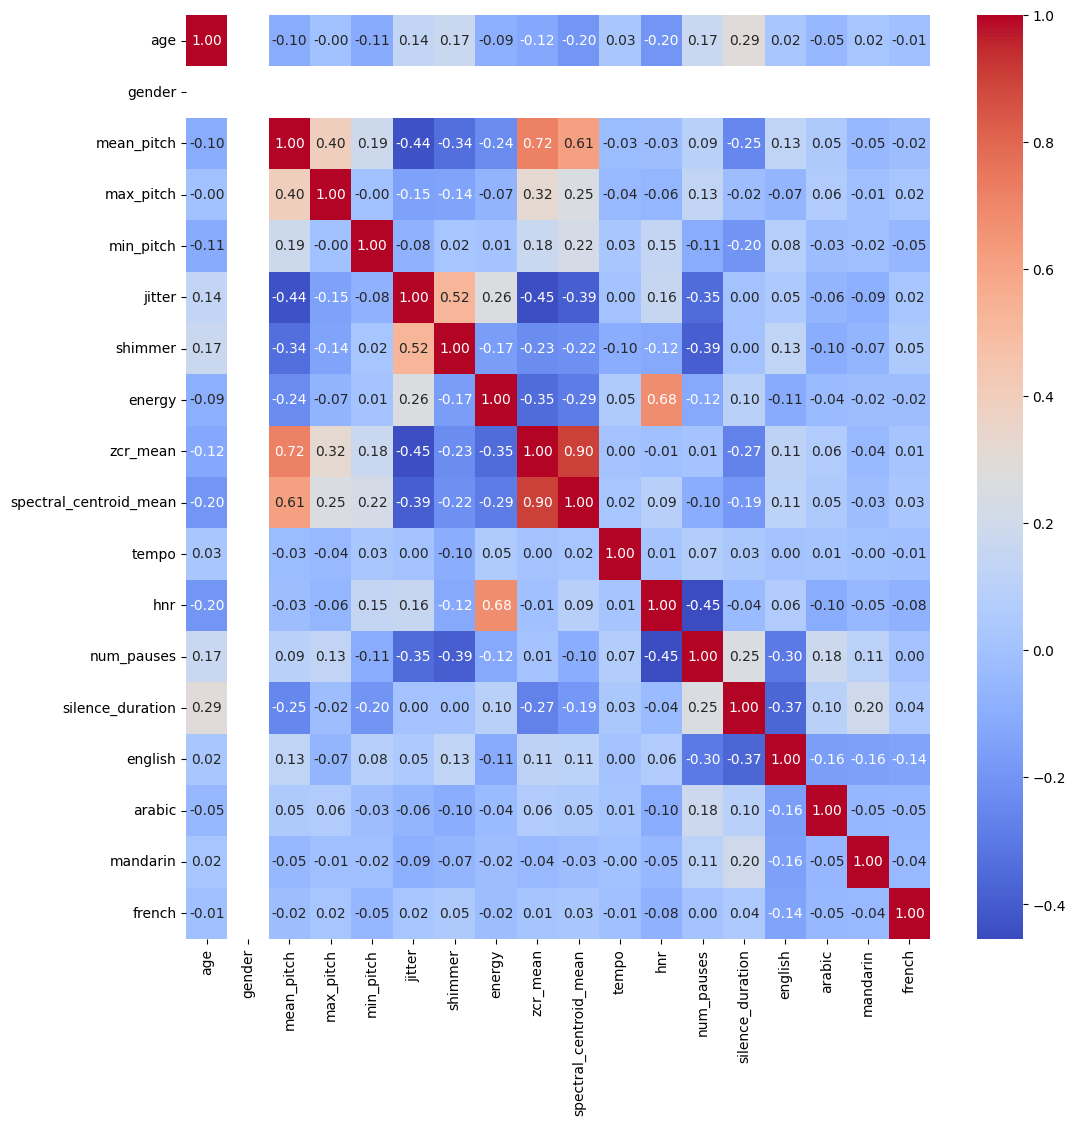

In [16]:
plt.figure(figsize=(12, 12))
sns.heatmap(df[df['gender']==1].corr(method='spearman'), annot=True, fmt=".2f", cmap='coolwarm')